In [ ]:
%pip install pandas numpy pytorch kagglehub kaggle

  Using cached pytorch-1.0.2.tar.gz (689 bytes)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pytorch
  Running setup.py clean for pytorch
Failed to build pytorch
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pytorch)


In [57]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils import data
import matplotlib.pyplot as plt
import kagglehub
import kaggle

In [33]:
kagglehub.login()
# key in secret.json
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
print(path)
train_data = pd.read_csv(path+"/train.csv")
test_data = pd.read_csv(path+"/test.csv")

/root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques


In [34]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))
# pd.concat -> 先把 train_data 和 test_data 合併 方便操作

print(all_features)


      MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0             60       RL         65.0     8450   Pave   NaN      Reg   
1             20       RL         80.0     9600   Pave   NaN      Reg   
2             60       RL         68.0    11250   Pave   NaN      IR1   
3             70       RL         60.0     9550   Pave   NaN      IR1   
4             60       RL         84.0    14260   Pave   NaN      IR1   
...          ...      ...          ...      ...    ...   ...      ...   
1454         160       RM         21.0     1936   Pave   NaN      Reg   
1455         160       RM         21.0     1894   Pave   NaN      Reg   
1456          20       RL        160.0    20000   Pave   NaN      Reg   
1457          85       RL         62.0    10441   Pave   NaN      Reg   
1458          60       RL         74.0     9627   Pave   NaN      Reg   

     LandContour Utilities LotConfig  ... ScreenPorch PoolArea PoolQC  Fence  \
0            Lvl    AllPub    Inside  ...  

## 正規化

In [37]:
# 找到所有非 object 的 features
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
print(numeric_features)

all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))

all_features[numeric_features] = all_features[numeric_features].fillna(0)
all_features = pd.get_dummies(all_features, dummy_na=True)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_Oth', 'SaleType_WD', 'SaleType_nan', 'SaleCondition_Abnorml',
       'SaleCondition_AdjLand', 'SaleCondition_Alloca', 'SaleCondition_Family',
       'SaleCondition_Normal', 'SaleCondition_Partial', 'SaleCondition_nan'],
      dtype='object', length=330)


In [39]:
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)

test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)

train_labels = torch.tensor(
    train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

In [42]:
loss = nn.MSELoss()

net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(train_features.shape[1], 512),
    nn.ReLU(),
    nn.Linear(512, 1)
)

def log_rmse(net, features, labels):
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

in_features = train_features.shape[1]

def train(net: nn.Sequential, train_features, train_labels, test_features, test_labels, num_epochs, learning_rate, weight_decay, batch_size):
    dataset = data.TensorDataset(train_features, train_labels) # 打包特徵與標籤
    train_iter = data.DataLoader(dataset, batch_size, shuffle=True, num_workers=4)
    optim = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)

    train_ls, test_ls = [], []
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optim.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optim.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls



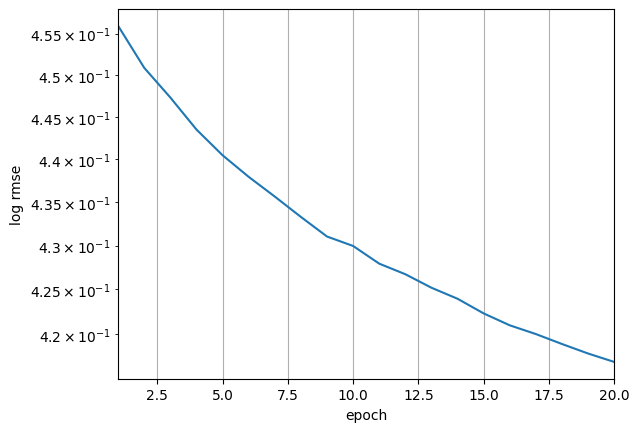

In [46]:
num_epochs, lr, weight_decay, batch_size = 20, 0.1, 1, 128
train_ls, _  = train(net, train_features, train_labels, test_features, None, num_epochs, lr, weight_decay, batch_size)
plt.plot(np.arange(1, num_epochs + 1), train_ls)

plt.xlabel('epoch')                              # 設置橫軸標籤
plt.ylabel('log rmse')                           # 設置縱軸標籤
plt.xlim([1, num_epochs])                        # 設置橫軸範圍
plt.yscale('log')                                # 設置縱軸為對數刻度
plt.grid(True)                                   # 加上網格線方便觀察
plt.show()                                       # 正式顯示圖表



In [72]:
preds = net(test_features).detach().numpy()
test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
submission.to_csv('submission.csv', index=False)